# 앙상블 모델 학습, 튜닝, 선정 및 시각화 파이프라인
본 노트북은 `modeling_basedon_EDA.ipynb`의 데이터를 기반으로, 여러 모델을 학습/튜닝하고 최적의 모델을 선정하여 앙상블하는 과정을 담고 있습니다.

In [1]:
import sys
import subprocess
import importlib.util
if importlib.util.find_spec("shap") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap

from itertools import combinations

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    VotingClassifier,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    make_scorer,
    roc_auc_score,
    roc_curve,
    auc,
)
import warnings
warnings.filterwarnings('ignore')

available_fonts = {font.name for font in fm.fontManager.ttflist}
if 'Malgun Gothic' in available_fonts:
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif 'AppleGothic' in available_fonts:
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


## 1. 데이터 로드 및 전처리

In [2]:
# 전처리가 완료된 데이터 로드
df = pd.read_csv("../../notebooks/01_data_collection/EDA/preprocessed_data/preprocessed.csv")

print("타깃 분포:")
print(df['is_churned'].value_counts())
print(f"이탈 비율: {df['is_churned'].mean():.2%}")


타깃 분포:
is_churned
0    2637
1     694
Name: count, dtype: int64
이탈 비율: 20.83%


In [3]:
# .env 로드 및 DB 연결
from dotenv import load_dotenv
import sys
sys.path.append('.') # db_utils.py 경로 대응
import db_utils

load_dotenv("../../.env", override=True)
db_utils.test_connection()

query = """
    SELECT channel_identifier, youtube_channel_id as channel_id, channel_name    
    FROM channel_info_table cit
"""
channel_df = db_utils.run_query(query, display=False)

df = pd.merge(df, channel_df, on="channel_identifier", how="left")
print(f"Merge 후 데이터 형태: {df.shape}")


DB 연결 성공
host     : 127.0.0.1:3306
database : youtube_model_db
Merge 후 데이터 형태: (3331, 45)


In [4]:
NON_FEATURE_COLUMNS = ["channel_identifier", "channel_id", "channel_name", "is_churned"]
ALL_FEATURES = [col for col in df.columns if col not in NON_FEATURE_COLUMNS]

X = df[ALL_FEATURES].copy()
y = df['is_churned']

train_full_X, test_X, train_full_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
train_X, valid_X, train_y, valid_y = train_test_split(
    train_full_X,
    train_full_y,
    test_size=0.25,
    random_state=42,
    stratify=train_full_y,
)

print(f"Feature count: {len(ALL_FEATURES)}")
print(f"Train: {train_X.shape}, Valid: {valid_X.shape}, Test: {test_X.shape}")


Feature count: 41
Train: (1998, 41), Valid: (666, 41), Test: (667, 41)


## 2. Recall-oriented model tuning

Use `RandomizedSearchCV` with a wider parameter space, class-imbalance controls, and F2-score refit. F2 puts more weight on recall than precision, which fits the churn-risk KPI better than ROC-AUC-only selection.


In [5]:
TARGET_RECALL = 0.80
RECALL_BUFFER = 0.10
THRESHOLD_RECALL_TARGET = min(TARGET_RECALL + RECALL_BUFFER, 0.95)
THRESHOLD_GRID = np.arange(0.05, 0.951, 0.005)
N_ITER = 40
CV_SPLITS = 5
REFIT_METRIC = "f2"

pos_weight = (train_y == 0).sum() / max((train_y == 1).sum(), 1)

# Class-imbalance aware model candidates.
models = {
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=1,
        verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1,
        n_jobs=1,
    ),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=1),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_jobs=1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(
        random_state=42,
        max_iter=5000,
        solver="liblinear",
    ),
}

# Wider parameter search space with recall-oriented imbalance controls.
param_distributions = {
    "XGBoost": {
        "n_estimators": [200, 300, 500, 700],
        "max_depth": [2, 3, 4, 5],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "gamma": [0, 0.5, 1.0],
        "reg_lambda": [1, 3, 5, 10],
        "scale_pos_weight": [1, pos_weight, pos_weight * 1.5, pos_weight * 2.0],
    },
    "LightGBM": {
        "n_estimators": [200, 300, 500, 700],
        "max_depth": [2, 3, 4, 5, -1],
        "num_leaves": [7, 15, 31, 63],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "min_child_samples": [10, 20, 40, 60],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
        "reg_lambda": [0, 1, 5, 10],
        "scale_pos_weight": [1, pos_weight, pos_weight * 1.5, pos_weight * 2.0],
    },
    "RandomForest": {
        "n_estimators": [300, 500, 700],
        "max_depth": [6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 8, 12],
        "min_samples_leaf": [1, 2, 3, 5],
        "max_features": ["sqrt", "log2", None],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    "ExtraTrees": {
        "n_estimators": [300, 500, 700],
        "max_depth": [6, 8, 10, 12, None],
        "min_samples_split": [2, 5, 8, 12],
        "min_samples_leaf": [1, 2, 3, 5],
        "max_features": ["sqrt", "log2", None],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    "GradientBoosting": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "subsample": [0.7, 0.85, 1.0],
        "min_samples_leaf": [1, 2, 5, 10],
    },
    "LogisticRegression": {
        "C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
        "penalty": ["l1", "l2"],
        "class_weight": ["balanced"],
    },
}

tuning_scoring = {
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "f2": make_scorer(fbeta_score, beta=2, zero_division=0),
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
}

def count_param_combinations(params):
    total = 1
    for values in params.values():
        total *= len(values)
    return total

def calculate_binary_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
    }

def threshold_key(metrics):
    meets_target = metrics["recall"] >= TARGET_RECALL
    return (meets_target, metrics["f1"], metrics["accuracy"], metrics["precision"])

def find_best_threshold(y_true, y_score, recall_target=THRESHOLD_RECALL_TARGET):
    metrics_list = [calculate_binary_metrics(y_true, y_score, t) for t in THRESHOLD_GRID]
    candidates = [m for m in metrics_list if m["recall"] >= recall_target]
    if candidates:
        return max(candidates, key=lambda m: (m["f1"], m["accuracy"], m["precision"]))
    return max(metrics_list, key=threshold_key)


In [6]:
best_estimators = {}
model_scores = {}
model_results = {}

print("--- Model tuning started ---")
print(
    f"N_ITER={N_ITER}, CV={CV_SPLITS}, refit={REFIT_METRIC}, "
    f"target_recall={TARGET_RECALL:.2f}, threshold_recall_target={THRESHOLD_RECALL_TARGET:.2f}"
)

for name, model in models.items():
    total_combinations = count_param_combinations(param_distributions[name])
    n_iter = min(N_ITER, total_combinations)
    print(f"[{name}] tuning... ({n_iter}/{total_combinations} sampled)")

    search = RandomizedSearchCV(
        model,
        param_distributions[name],
        n_iter=n_iter,
        scoring=tuning_scoring,
        refit=REFIT_METRIC,
        cv=CV_SPLITS,
        random_state=42,
        n_jobs=-1,
        return_train_score=False,
    )
    search.fit(train_X, train_y)

    best_estimators[name] = search.best_estimator_

    valid_probs = search.predict_proba(valid_X)[:, 1]
    valid_metrics = find_best_threshold(valid_y, valid_probs)
    model_results[name] = {
        **valid_metrics,
        "best_params": search.best_params_,
        "cv_best_f2": search.best_score_,
    }
    model_scores[name] = threshold_key(valid_metrics)

    print(f"Best Params: {search.best_params_}")
    print(
        f"Valid Threshold: {valid_metrics['threshold']:.3f} | "
        f"Recall: {valid_metrics['recall']:.4f} | "
        f"F1: {valid_metrics['f1']:.4f} | "
        f"Accuracy: {valid_metrics['accuracy']:.4f} | "
        f"ROC-AUC: {valid_metrics['roc_auc']:.4f}\n"
    )


--- Model tuning started ---
N_ITER=40, CV=5, refit=f2, target_recall=0.80, threshold_recall_target=0.90
[XGBoost] tuning... (40/82944 sampled)
Best Params: {'subsample': 0.85, 'scale_pos_weight': np.float64(5.704326923076923), 'reg_lambda': 10, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}
Valid Threshold: 0.355 | Recall: 0.9065 | F1: 0.5081 | Accuracy: 0.6336 | ROC-AUC: 0.8499

[LightGBM] tuning... (40/184320 sampled)
Best Params: {'subsample': 0.7, 'scale_pos_weight': np.float64(7.605769230769231), 'reg_lambda': 0, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 60, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.85}
Valid Threshold: 0.430 | Recall: 0.9065 | F1: 0.5316 | Accuracy: 0.6667 | ROC-AUC: 0.8523

[RandomForest] tuning... (40/1440 sampled)
Best Params: {'n_estimators': 700, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 6, 'class_weight':

## 3. Validation-based ensemble selection

Build soft-voting ensemble candidates from the tuned models, choose the best combination on the validation set, and keep the selected decision threshold for final test evaluation.


In [7]:
# Select the best voting ensemble on the validation set.
ensemble_candidates = []
candidate_names = list(best_estimators.keys())
max_ensemble_size = min(4, len(candidate_names))

for size in range(2, max_ensemble_size + 1):
    for names in combinations(candidate_names, size):
        valid_probs = np.mean(
            [best_estimators[name].predict_proba(valid_X)[:, 1] for name in names],
            axis=0,
        )
        valid_metrics = find_best_threshold(valid_y, valid_probs)
        ensemble_candidates.append({
            **valid_metrics,
            "models": names,
            "selection_key": threshold_key(valid_metrics),
        })

best_ensemble_candidate = max(
    ensemble_candidates,
    key=lambda item: item["selection_key"],
)
selected_model_names = list(best_ensemble_candidate["models"])
ensemble_threshold = best_ensemble_candidate["threshold"]

print("--- Selected ensemble models ---")
for idx, name in enumerate(selected_model_names, start=1):
    result = model_results[name]
    print(
        f"{idx}. {name} | valid recall={result['recall']:.4f}, "
        f"f1={result['f1']:.4f}, accuracy={result['accuracy']:.4f}"
    )

print(
    f"Validation ensemble threshold={ensemble_threshold:.3f} | "
    f"recall={best_ensemble_candidate['recall']:.4f}, "
    f"f1={best_ensemble_candidate['f1']:.4f}, "
    f"accuracy={best_ensemble_candidate['accuracy']:.4f}, "
    f"roc_auc={best_ensemble_candidate['roc_auc']:.4f}"
)

ensemble_estimators = [(name, best_estimators[name]) for name in selected_model_names]
ensemble_model = VotingClassifier(
    estimators=ensemble_estimators,
    voting="soft",
)
ensemble_model.fit(train_X, train_y)


--- Selected ensemble models ---
1. XGBoost | valid recall=0.9065, f1=0.5081, accuracy=0.6336
2. LightGBM | valid recall=0.9065, f1=0.5316, accuracy=0.6667
3. LogisticRegression | valid recall=0.9137, f1=0.5080, accuracy=0.6306
Validation ensemble threshold=0.385 | recall=0.9137, f1=0.5370, accuracy=0.6712, roc_auc=0.8557


VotingClassifier(estimators=[('XGBoost',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=1.0, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None, gamma=0.5,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            lear...
                              LGBMClassifier(colsample_bytree=0.85,
                                             learning_rate=0.03, max_depth=4,
                                             min_child_samples=60,
                                             n_estimators=200, n_jobs=1,
                                             num_leaves=15, random_state=42,
                                             reg_lambda=0,
                                             scale_pos_weight=np.float64(7.605769230769231),
                                             subsample=0.7, verbose=-1)),
                             ('LogisticRegression',
                              LogisticRegression(C=0.1, class_weight='balanced',
                                                 max_iter=5000, penalty='l1',
                                                 random_state=42,
                                                 solver='liblinear'))],
                 voting='soft')

In [8]:
# Final test evaluation uses the threshold selected on the validation set.
ens_probs = ensemble_model.predict_proba(test_X)[:, 1]
ens_preds = (ens_probs >= ensemble_threshold).astype(int)

ens_acc = accuracy_score(test_y, ens_preds)
ens_precision = precision_score(test_y, ens_preds, zero_division=0)
ens_recall = recall_score(test_y, ens_preds, zero_division=0)
ens_f1 = f1_score(test_y, ens_preds, zero_division=0)
ens_f2 = fbeta_score(test_y, ens_preds, beta=2, zero_division=0)
ens_auc = roc_auc_score(test_y, ens_probs)

test_metrics = {
    "threshold": ensemble_threshold,
    "accuracy": ens_acc,
    "precision": ens_precision,
    "recall": ens_recall,
    "f1": ens_f1,
    "f2": ens_f2,
    "roc_auc": ens_auc,
}

print("[Final ensemble test performance]")
print(f"Threshold: {ensemble_threshold:.3f}")
print(f"Accuracy: {ens_acc:.4f}")
print(f"Precision: {ens_precision:.4f}")
print(f"Recall: {ens_recall:.4f}")
print(f"F1-score: {ens_f1:.4f}")
print(f"F2-score: {ens_f2:.4f}")
print(f"ROC-AUC: {ens_auc:.4f}")

if ens_recall < TARGET_RECALL:
    print(
        f"WARNING: test recall {ens_recall:.4f} is below target {TARGET_RECALL:.2f}. "
        "Try increasing RECALL_BUFFER or N_ITER, or adding more signal features."
    )

print("\nClassification Report:\n", classification_report(test_y, ens_preds, zero_division=0))


[Final ensemble test performance]
Threshold: 0.385
Accuracy: 0.6522
Precision: 0.3604
Recall: 0.8633
F1-score: 0.5085
F2-score: 0.6749
ROC-AUC: 0.7949

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.60      0.73       528
           1       0.36      0.86      0.51       139

    accuracy                           0.65       667
   macro avg       0.65      0.73      0.62       667
weighted avg       0.82      0.65      0.68       667



## 4. 평가 시각화 (그래프)

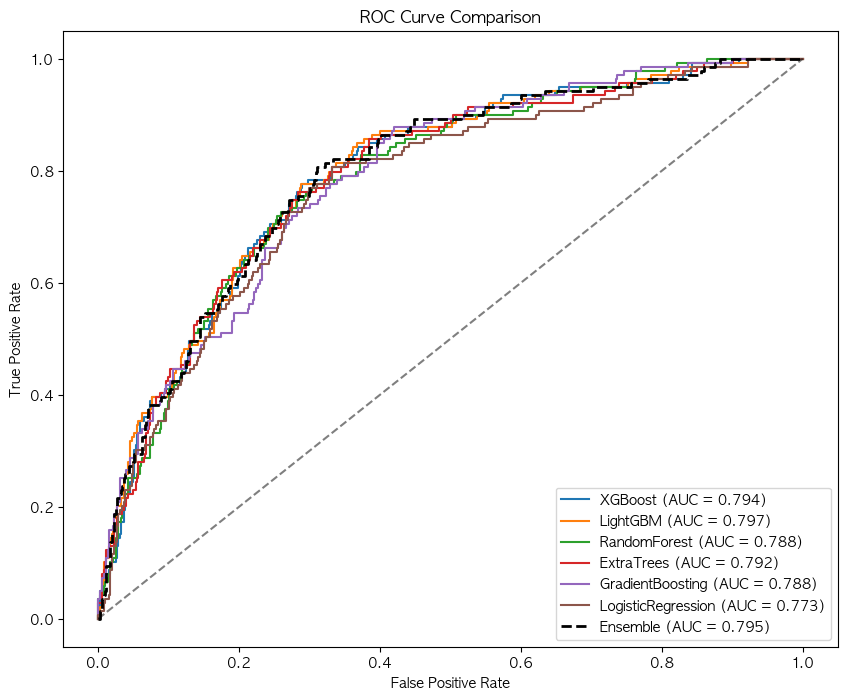

In [9]:
# 1) ROC Curve comparison on the test set.
plt.figure(figsize=(10, 8))
model_test_auc = {}

for name, model in best_estimators.items():
    probs = model.predict_proba(test_X)[:, 1]
    auc_value = roc_auc_score(test_y, probs)
    model_test_auc[name] = auc_value
    fpr, tpr, _ = roc_curve(test_y, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_value:.3f})")

ens_fpr, ens_tpr, _ = roc_curve(test_y, ens_probs)
plt.plot(
    ens_fpr,
    ens_tpr,
    label=f"Ensemble (AUC = {ens_auc:.3f})",
    color='black',
    linewidth=2,
    linestyle='--',
)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()


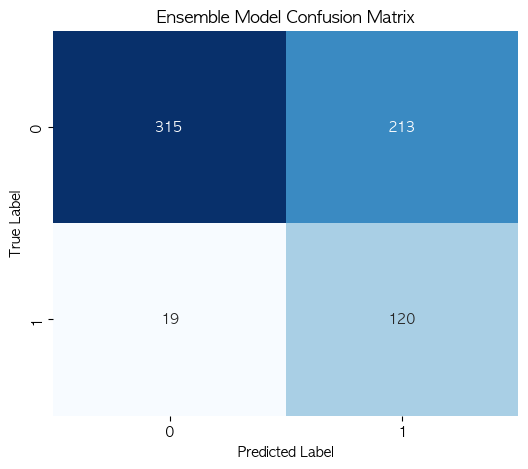

In [10]:
# 2) Confusion Matrix (Ensemble)
cm = confusion_matrix(test_y, ens_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Ensemble Model Confusion Matrix')
plt.show()


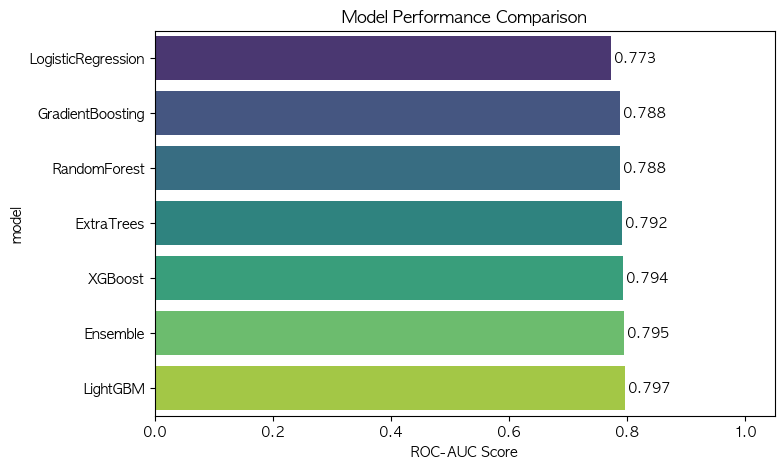

In [11]:
# 3) ROC-AUC bar chart on the test set.
if "model_test_auc" not in globals():
    model_test_auc = {
        name: roc_auc_score(test_y, model.predict_proba(test_X)[:, 1])
        for name, model in best_estimators.items()
    }

performance_df = pd.DataFrame(
    {
        "model": list(model_test_auc.keys()) + ["Ensemble"],
        "roc_auc": list(model_test_auc.values()) + [ens_auc],
    }
).sort_values("roc_auc", ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=performance_df, x="roc_auc", y="model", palette='viridis')
for i, score in enumerate(performance_df["roc_auc"]):
    plt.text(score + 0.005, i, f"{score:.3f}", va='center')

plt.xlim(0, 1.05)
plt.xlabel('ROC-AUC Score')
plt.title('Model Performance Comparison')
plt.show()


## 5. SHAP feature importance

Use the first selected tree-based ensemble member for SHAP interpretation because direct SHAP explanation of a soft-voting ensemble is more complex.


'XGBoost' model-based SHAP analysis


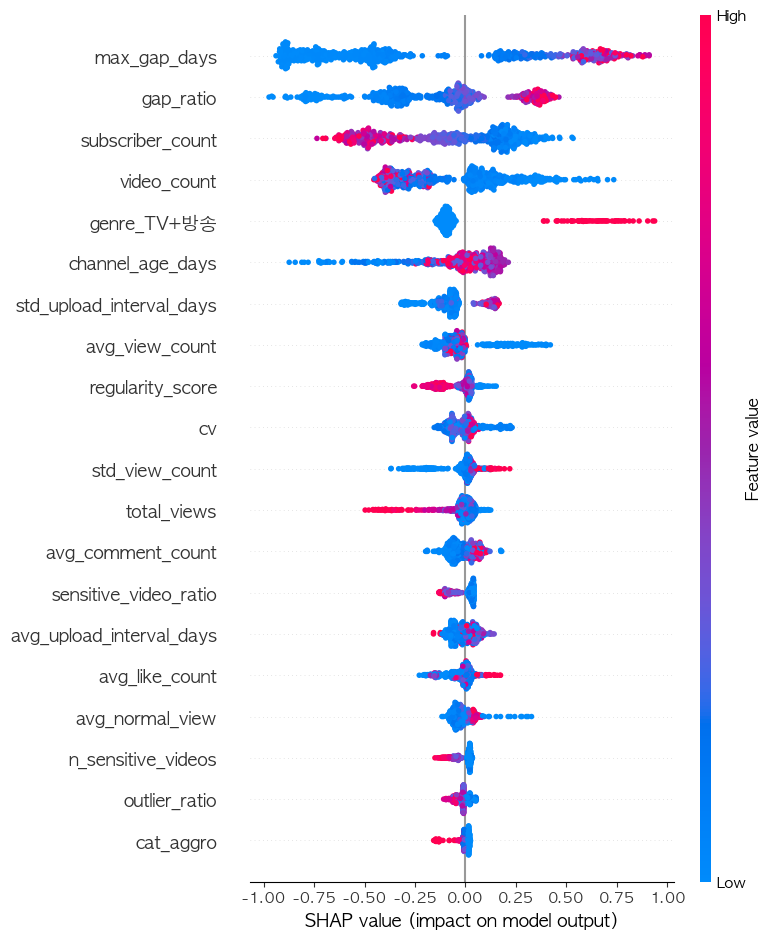

In [12]:
# Use the first selected tree-based model for SHAP interpretation.
tree_model_names = [
    name for name in selected_model_names
    if name in {"XGBoost", "LightGBM", "RandomForest", "ExtraTrees", "GradientBoosting"}
]
top1_model_name = tree_model_names[0] if tree_model_names else selected_model_names[0]
top1_model = best_estimators[top1_model_name]

print(f"'{top1_model_name}' model-based SHAP analysis")
try:
    explainer = shap.TreeExplainer(top1_model)
    shap_values_top1 = explainer(test_X)
    shap.summary_plot(shap_values_top1, test_X)
except Exception:
    explainer = shap.Explainer(top1_model.predict, train_X)
    shap_values_top1 = explainer(test_X.iloc[:100])
    shap.summary_plot(shap_values_top1, test_X.iloc[:100])


# 학습된 모델저장

In [13]:
import joblib

model_package = {
    "model": ensemble_model,
    "decision_threshold": ensemble_threshold,
    "target_recall": TARGET_RECALL,
    "threshold_recall_target": THRESHOLD_RECALL_TARGET,
    "selected_models": selected_model_names,
    "features": ALL_FEATURES,
    "validation_metrics": best_ensemble_candidate,
    "test_metrics": test_metrics,
}

joblib.dump(model_package, "best_ensemble_model.pkl")


['best_ensemble_model.pkl']